In [1]:
# needed imports
import os
import gzip
import tarfile
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, utils, datasets
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# load in and format the dataset
class CancerDataset(Dataset):
  def __init__(self, root, download=True, size=512, train=True):
    if download and not os.path.exists(os.path.join(root, 'cancer_data')):
      datasets.utils.download_url('http://liftothers.org/cancer_data.tar.gz', root, 'cancer_data.tar.gz', None)
      self.extract_gzip(os.path.join(root, 'cancer_data.tar.gz'))
      self.extract_tar(os.path.join(root, 'cancer_data.tar'))

    postfix = 'train' if train else 'test'
    root = os.path.join(root, 'cancer_data', 'cancer_data')
    self.dataset_folder = datasets.ImageFolder(os.path.join(root, 'inputs_' + postfix) ,transform = transforms.Compose([transforms.Resize(size),transforms.ToTensor()]))
    self.label_folder = datasets.ImageFolder(os.path.join(root, 'outputs_' + postfix) ,transform = transforms.Compose([transforms.Resize(size),transforms.ToTensor()]))

  @staticmethod
  def extract_gzip(gzip_path, remove_finished=False):
    print('Extracting {}'.format(gzip_path))
    with open(gzip_path.replace('.gz', ''), 'wb') as out_f, gzip.GzipFile(gzip_path) as zip_f:
      out_f.write(zip_f.read())
    if remove_finished:
      os.unlink(gzip_path)

  @staticmethod
  def extract_tar(tar_path):
    print('Untarring {}'.format(tar_path))
    z = tarfile.TarFile(tar_path)
    z.extractall(tar_path.replace('.tar', ''))

  def __getitem__(self,index):
    img = self.dataset_folder[index]
    label = self.label_folder[index]
    return img[0],label[0][0]

  def __len__(self):
    return len(self.dataset_folder)

train_dataset = CancerDataset("/tmp/Datasets/cancer", train=True)
val_dataset = CancerDataset("/tmp/Datasets/cancer", train=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=True)

@torch.no_grad()
def cancer_detection_accuracy(y_hat, y):
    y_hat = y_hat.to(device)
    y = y.to(device)
    y_hat = y_hat.argmax(1)
    pred = (y == y_hat).float()
    return torch.mean(pred).item()

@torch.no_grad()
def validation(net, val_loader):

    average_loss_lst = []
    accuracy_lst = []

    net = net.to(device)

    for x,y in val_loader:

      x = x.to(device)
      y = y.to(device)

      y_hat = net(x)

      accuracy_lst.append(cancer_detection_accuracy(y_hat, y))
      y = y.long()
      average_loss_lst.append(F.cross_entropy(y_hat,y).item())

    average_loss = np.mean(average_loss_lst)
    accuracy = np.mean(accuracy_lst)

    return average_loss, accuracy

@torch.no_grad()
def get_prediction(net, x):
    x = x.to(device)
    net = net.to(device)
    y_hat = net(x)
    pred = torch.argmax(y_hat, dim=1)
    pred_im = pred.squeeze(0)
    return pred_im.cpu()

100%|██████████| 2.75G/2.75G [02:04<00:00, 22.2MB/s]


Extracting /tmp/Datasets/cancer/cancer_data.tar.gz
Untarring /tmp/Datasets/cancer/cancer_data.tar


/tmp/ipykernel_24347/3138384845.py:42: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  z.extractall(tar_path.replace('.tar', ''))


In [2]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=2):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(64, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.down3(self.pool2(x2))

        x4 = self.bottleneck(self.pool3(x3))

        x = self.up3(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.conv3(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = self.conv1(x)

        return self.out_conv(x)

Epoch 1/10 [train]: 100%|██████████| 336/336 [05:30<00:00,  1.02it/s]


Epoch 1: train_loss=0.5535, val_loss=0.3300, val_acc=0.9007


Epoch 2/10 [train]: 100%|██████████| 336/336 [05:32<00:00,  1.01it/s]


Epoch 2: train_loss=0.4365, val_loss=0.3638, val_acc=0.9012


Epoch 3/10 [train]: 100%|██████████| 336/336 [05:37<00:00,  1.00s/it]


...

Epoch 8: train_loss=0.2578, val_loss=0.2900, val_acc=0.9129


Epoch 9/10 [train]: 100%|██████████| 336/336 [05:22<00:00,  1.04it/s]


Epoch 9: train_loss=0.2424, val_loss=0.2830, val_acc=0.9146


Epoch 10/10 [train]: 100%|██████████| 336/336 [05:29<00:00,  1.02it/s]


Epoch 10: train_loss=0.2384, val_loss=0.2853, val_acc=0.9172


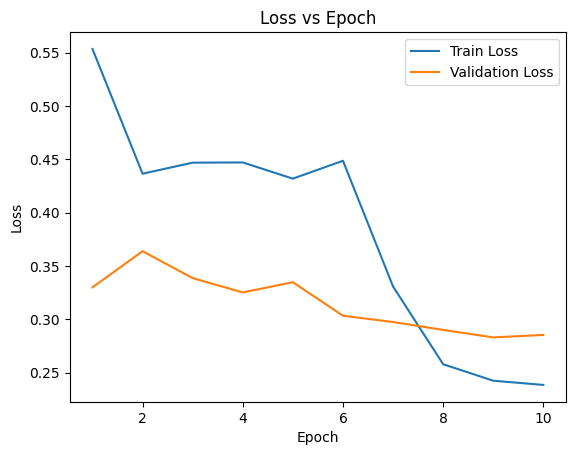

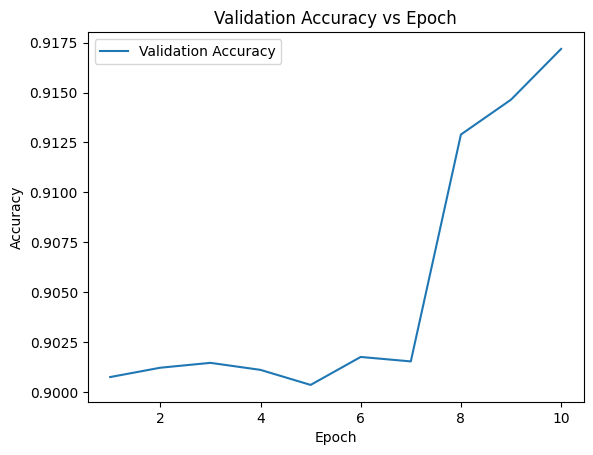

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
def train_unet(net, train_loader, val_loader, epochs=10, lr=1e-3):

    net = net.to(device)
    optimizer = optim.Adam(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accs = []

    for epoch in range(epochs):
        net.train()
        running_loss = 0

        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]"):

            x = x.to(device)
            y = y.to(device).long()

            optimizer.zero_grad()
            y_hat = net(x)

            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        net.eval()
        val_loss = 0
        accs = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device).long()

                y_hat = net(x)

                loss = criterion(y_hat, y)
                val_loss += loss.item()

                accs.append(cancer_detection_accuracy(y_hat, y))

        val_loss /= len(val_loader)
        val_acc = np.mean(accs)

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    return train_losses, val_losses, val_accs

net = UNet()
train_losses, val_losses, val_accs = train_unet(net, train_loader, val_loader)

def plot(train_losses, val_losses, val_accs):
    epochs = range(1, len(train_losses) + 1)

    plt.figure()
    plt.title("Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")

    plt.legend()
    plt.show()

    plt.figure()
    plt.title("Validation Accuracy vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.plot(epochs, val_accs, label="Validation Accuracy")

    plt.legend()
    plt.show()

plot(train_losses, val_losses, val_accs)

torch.save(net.state_dict(), "bottom_and_middle_skip_unet.pth")

from google.colab import files
files.download("bottom_and_middle_skip_unet.pth")